In [1]:
import sys
import os
os.chdir('/zhome/71/c/146676/main/')
import time
import SimpleITK as sitk
import numpy as np
from astropy.io import fits
from helpers import module_auxiliary as ma
import tifffile
from multiprocessing import Pool
import matplotlib.pyplot as plt
from helpers import extended_data as ed
from cil.recon import FBP
#from cil.plugins.astra import FBP
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.optimisation.functions import L2NormSquared, L1Norm, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, \
                                       ZeroFunction
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
import h5py
from cil.utilities.display import show_geometry
from scipy.ndimage import uniform_filter1d
from cil.processors import Slicer
from scipy.interpolate import interp1d
import cv2
import hdf5plugin
from scipy.ndimage import uniform_filter
from scipy.ndimage import label, sum_labels
from cil.plugins.astra import ProjectionOperator
from scipy.ndimage import label

In [2]:
A1 = np.arange(339, 449+1, 2)
A2 = np.arange(455, 471+1, 2)
A3 = np.arange(475, 487+1, 2)
A = np.concatenate([A1,A2,A3])
# A = A1
data_path = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal/integrated-####.h5'
data_files = ma.generate_paths(data_path, A)
data_att_path = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal/scan-####_xspress3-dtc-2d.h5'
data_att_files = ma.generate_paths(data_att_path, A)
output_path = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-####.h5'
output_files = ma.generate_paths(output_path, A)


c0, c1 = 0, 667
y0,y1 = 130, 230
alpha_dc_ = 10
q_key = 'crystal_q-80'
p_key = 'powder_q-80'

i = 20

print('Loading absorption data for slice', i)
with h5py.File(data_att_files[i], 'r') as file:
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_att = dtc['window_counts'][:][:,0].reshape(181,362).astype(np.float32)



print('Loading integrated diffraction data')
with h5py.File(data_files[i], 'r') as file:
    datasetq = file[q_key][:]
    datasetq = np.sum(datasetq,axis=2)

    datasetp = file[p_key][:]

print('Loaded data for slice ', i)

dataq = np.transpose(datasetq/200,[2,0,1])[:][c0:c1].astype(np.float32)
datap = np.transpose(datasetp/200,[2,0,1])[:][c0:c1].astype(np.float32)


Loading absorption data for slice 20
Loading integrated diffraction data
Loaded data for slice  20


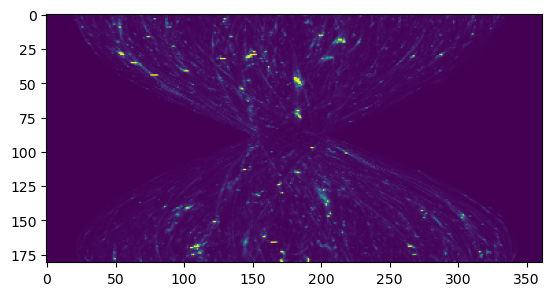

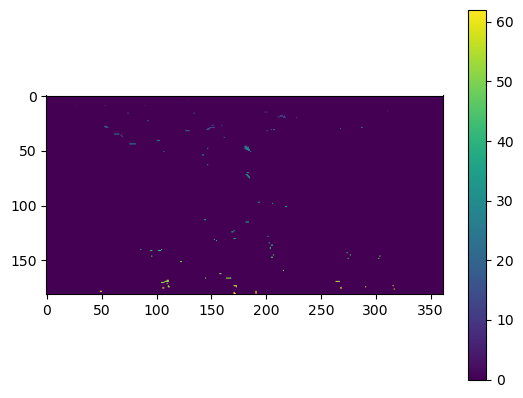

In [3]:
i_c = 200
d_channels = []
data_channel = dataq[i_c].astype(np.float32)
blurred = cv2.GaussianBlur(data_channel, (105, 105), 0)  # Adjust kernel size based on spot size
high_pass = cv2.subtract(data_channel, blurred)
q = np.percentile(high_pass, 99.7)

thresholded= (high_pass > q).astype(np.float32)  # Convert to 0 and 255
thresholded_blurred = cv2.GaussianBlur(thresholded, (3, 3), 0) 

labeled_array, num_features = label(thresholded_blurred)
labeled_array = labeled_array*(thresholded.astype(bool))

d_channels.append(data_channel)

component_sizes = np.bincount(labeled_array.ravel())[1:]  # Ignore background (label=0)
component_weights = sum_labels(data_channel, labeled_array, index=np.arange(1, num_features + 1))
sorting_metric = component_sizes * component_weights
sorted_labels = np.argsort(sorting_metric)[::-1]

nc, na, nx = np.shape(dataq)

plt.imshow(dataq[200])
plt.clim([0,10])
plt.show()

plt.imshow(labeled_array)
#plt.clim([0,10])
plt.colorbar()
plt.show()

In [4]:
S = labeled_array
# S is your labeled sinogram: shape (num_angles, num_detectors)
# Values: 0 = background, 1–60 = blobs

theta_vals = np.linspace(0, np.pi, S.shape[0], endpoint=False)
theta_idx, s_idx = np.nonzero(S)

labels = S[theta_idx, s_idx]
theta = theta_vals[theta_idx]
s = s_idx.astype(float)

points = np.column_stack((theta, s))  # shape (N, 2)


In [5]:
class SinusoidModel:
    def estimate(self, data):
        theta, s = data[:, 0], data[:, 1]
        A = np.column_stack((np.cos(theta), np.sin(theta)))
        try:
            x0_y0, _, _, _ = np.linalg.lstsq(A, s, rcond=None)
            self.params_ = x0_y0
            return True
        except:
            return False

    def residuals(self, data):
        theta, s = data[:, 0], data[:, 1]
        x0, y0 = self.params_
        s_pred = (x0) * np.cos(theta) + (y0) * np.sin(theta)+181
        return np.abs(s - s_pred)

In [20]:
theta_last = theta_vals[-1]
theta_mid = theta_vals[len(theta_vals)//2]

def model_is_valid(x0, y0):
    #s0 = x0  # s(θ=0)
    #s_last = x0 * np.cos(theta_last) + y0 * np.sin(theta_last)
    
    return (
        #0 <= s0 <= 362 and
        #0 <= s_last <= 362 and
        #150 <= y0 <= 200 and
        abs(x0) < 100 and
        abs(y0) < 100
    )

In [23]:
from skimage.measure import ransac

remaining_points = points.copy()
identified_models = []

while len(remaining_points) >= 30:
    model = SinusoidModel()
    try:
        best_model, inliers = ransac(
            remaining_points,
            model_class=SinusoidModel,
            min_samples=2,
            residual_threshold=2000.0,
            max_trials=3
        )
    except ValueError:
        break

    if inliers.sum() < 3:
        break


    x0, y0 = best_model.params_
    if not model_is_valid(x0, y0):
        continue  # discard this model



    identified_models.append(((x0, y0), remaining_points[inliers]))
    remaining_points = remaining_points[~inliers]



KeyboardInterrupt: 

In [18]:
for i, ((x0, y0), pts) in enumerate(identified_models):
    print(f"Model {i+1}: x0={x0:.2f}, y0={y0:.2f}, {len(pts)} inliers")


Model 1: x0=138.54, y0=69.96, 95 inliers
Model 2: x0=-133.85, y0=122.06, 74 inliers


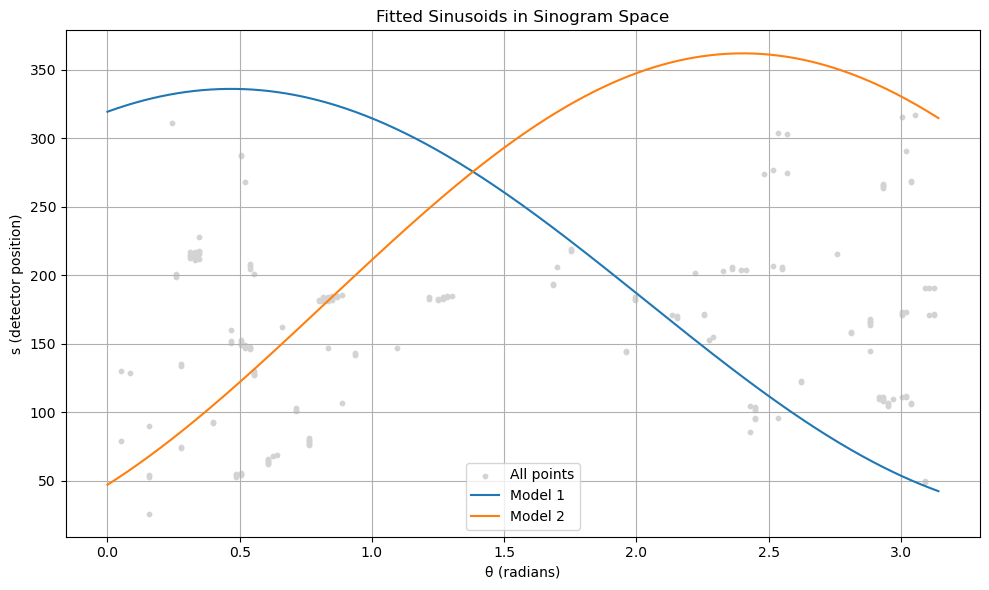

In [19]:
import matplotlib.pyplot as plt

# Scatter all original blob points
plt.figure(figsize=(10, 6))
plt.scatter(points[:, 0], points[:, 1], s=10, color='lightgray', label='All points')

# Plot fitted sinusoids
theta_plot = np.linspace(0, np.pi, 500)

for i, ((x0, y0), _) in enumerate(identified_models):
    s_plot = (x0) * np.cos(theta_plot) + (y0) * np.sin(theta_plot)+181
    plt.plot(theta_plot, s_plot, label=f'Model {i+1}')

plt.xlabel('θ (radians)')
plt.ylabel('s (detector position)')
plt.title('Fitted Sinusoids in Sinogram Space')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()